# QSAR - Random Forest Classification 
A QSAR classification model for small-molecule BRD4 inhibitors trained with published inhibitors from ChEMBL ([EDA notebook](01_eda/01_pre_process.ipynb)).  

# Setup Code
## Environment

In [19]:
### use brd4

import sys

print(sys.executable)

/home/oskar/anaconda3/envs/brd4/bin/python


## Imports

In [ ]:
### Standard imports
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rdkit as rd
import seaborn as sns
from tqdm import tqdm
import sklearn as sk

In [ ]:
### Specific imports
import astartes as at

## Jupyter Settings

In [21]:
### Random seed - using the same seed for robustness
SEED = 0
np.random.seed(SEED)

### NumPy arrays - floats
np.set_printoptions(
    precision=2,  # round values
    suppress=True,
)  # avoid scientific notation

### pandas DataFrames
pd.set_option("display.float_format", "{:.2f}".format)  # Round to 2 decimal places

### Initialize tqdm for pandas
tqdm.pandas()

### Suppress RDKit logs
rd.RDLogger.DisableLog("rdApp.*")

### Re-enable logging if needed
# rd.RDLogger.EnableLog('rdApp.*')

## Utils
- `utils/pd_mol.py` contains individual functions for processing rdkit mol objects in pandas DataFrames. 
- `utils/sk_qsar.py` contains individual functions for bulding QSAR models with scikit-learn. 
- The class [`MorganSimilarity`](`../utils/similarity_sali.py`) is used as container for the training data. 

In [22]:
### Add the utils directory to the path
sys.path.append(os.path.abspath("../utils"))
from pd_mol import render_mol
from similarity_sali import MorganSimilarity
import sk_qsar

# Data
Load data saved in `MorganSimilarity` class in [feature selection](../03_QSAR_classifier/01_feature_selection.ipynb). 

In [23]:
### Load the morgan object
with open("../data/03_morgan.pkl", "rb") as file:
    morgan = pickle.load(file)

### Morgan fingerprints
morgan.fp

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(2397, 2048))

# Test Set
## Kennard-Stone Train-test-split
The test set is selected using the [Kennard-Stone](https://jacksonburns.github.io/astartes/index.html) algorithm. This ensures that the training set is structurally as diverse as possible, by maximizing the distance between test cmpds. Implications:
- Allows for the use of a small test set. 
- Maximizes the chemical space covered by the training set. 
- Reduces the value of the test set somewhat, as the distance to training set is minimal.   

In [24]:
### Train-test-split unsing Kennard-Stone and Morgan fingerprints
X_train, X_test, train_idx, test_idx = at.train_test_split(
    morgan.fp,
    morgan.df.index.values,
    test_size=0.10,
    train_size=0.90,
    sampler="kennard_stone",
)

### Split labels
y_train = morgan.df.loc[train_idx, 'active'].values
y_test = morgan.df.loc[test_idx, 'active'].values

Visualizing the data split in a t-SNE plot

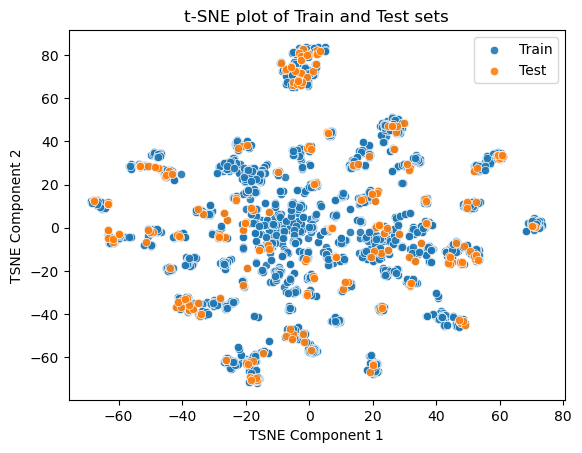

In [27]:
### TSNE plot of data split
sk_qsar.plot_tsne(X_train, X_test, learning_rate=200)

# Hyperparameter tuning
Out-of-bag (OOF) scores will be used for initial hyperparameter evaluation. Thus, dimensionality reduction can be performed on the training and test sets. Due to the balanced nature of the data set **accuracy** can be used as the only metric.  
## PCA


In [12]:
### Instantiate PCA object
pca_32 = sk.decomposition.PCA(n_components=32)

### Fit model and transform the training data
X_train_32 = pca_32.fit_transform(X_train)

### Transform the test data
X_test_32 = pca_32.transform(X_test)

## Default Hyperparameters

In [ ]:
### Instantiate Random Forest Classifier
rf_default = sk.ensemble.RandomForestClassifier(
    oob_score=True,  
    random_state=SEED,
)

### Fit the training data
rf_default.fit(X_train_32, y_train)

### Get the OOB score
default_oob = rf_default.oob_score_
print(f'OOB score: {default_oob:.3f}')

### Print parameters
rf_default.get_params()

OOB score: 0.887


{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': True,
 'random_state': 0,
 'verbose': 0,
 'warm_start': False}

## Single-Parameter Screening
To get an idea of the impact of every hyperparameter only one is changed starting from a default setting.

In [ ]:
def sps_oob(X, y, default_params, hyperparameter, value):
    """
    Perform a single-parameter screen using OOB score.
    """
    
    ### Convert the value to numeric
    value = pd.to_numeric(value, errors="ignore")

    ### Update the hyperparameter
    params = default_params.copy()
    params[hyperparameter] = value
                
    ### Initialize the Random Forest Classifier
    rf = sk.ensemble.RandomForestClassifier(**params)

    ### Fit the data
    rf.fit(X, y)

    ### Return the out-of-bag accuracy score
    return rf.oob_score_

In [ ]:
### Default parameters (to keep fixed)
default_params = {
    'n_estimators': 100,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'sqrt',
    'criterion': 'gini',
    'oob_score': True,
    'random_state': SEED,
}

### Define the hyperparameters to test (maintain shape)
param_grid = {
    'n_estimators': [10, 25, 50, 200],
    'max_depth': [5, 10, 20, 30],
    'min_samples_split': [4, 6, 8, 16],
    'min_samples_leaf': [2, 3, 4, 8],
    'max_features': [0.3, 1.0, 'log2', 'log2'],
    'criterion': ['entropy', 'entropy', 'entropy', 'entropy'],
}

### Convert directly to DataFrame
wide_sps_df = pd.DataFrame(param_grid)

### Reshape into tall format
sps_df = wide_sps_df.melt(var_name="hyperparameter", value_name="value").drop_duplicates()

### Perform the single-parameter screen
sps_df['oob_score'] = sps_df.progress_apply(lambda row: sps_oob(X_train_32, y_train, default_params, row['hyperparameter'], row['value']), axis=1)

  0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_92630/3438178003.py:7: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  value = pd.to_numeric(value, errors="ignore")
/home/oskar/anaconda3/envs/brd4/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
 10%|█         | 2/20 [00:00<00:02,  8.59it/s]/tmp/ipykernel_92630/3438178003.py:7: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  value = pd.to_numeric(value, errors="ignore")
 15%|█▌        | 3/20 [00:00<00:05,  3.40it/s]/tmp/ipykernel_92630/3438178003.py:7: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions 

In [ ]:
### Add default values for comparison
wide_default_df = pd.DataFrame(default_params, index=[0])

### Reshape into tall format
default_df = wide_default_df.melt(var_name="hyperparameter", value_name="value").head(6).fillna('None')
default_df['oob_score'] = default_oob

### Combine the DataFrames
full_sps_df = pd.concat([sps_df, default_df], axis=0, ignore_index=True)


### Visualization of the single-parameter screen
Each subplot shows the out-of bag accuracy score one hyperparameter (the score using the default value on the very right). In summary:
- The default settings are not surpassed, but there is clear potential to reduce the model's complexity with minimal loss.
- The number of trees `n_estimators` will be reduced to `50`. Saving computational cost and also reducing the models complexity somewhat. 
- The number of consecutive splits `max_depth` will be investiagted in more detail. It can be limited to `~10` or`~20`. The highest potential of increased generalization is expected here. 
- Larger leaf nodes can be enforced by the connected hyperparameters `min_samples_split` and `min_samples_leaf`. Smoother decision boundaries can be achieved by `~8` and `~4`, respectively.   
- With the lower numbers of features for the bootstrapping sample `max_features` more bias is introduced. The default `sqrt` in 6 features per tree (sqrt(32) ≈ 5.66 ) and `log2`(5 features per tree) will be investigated.  
- The nature of the function for evaluating the split purity is of little impact. Default `criterion = gini` will be used.  

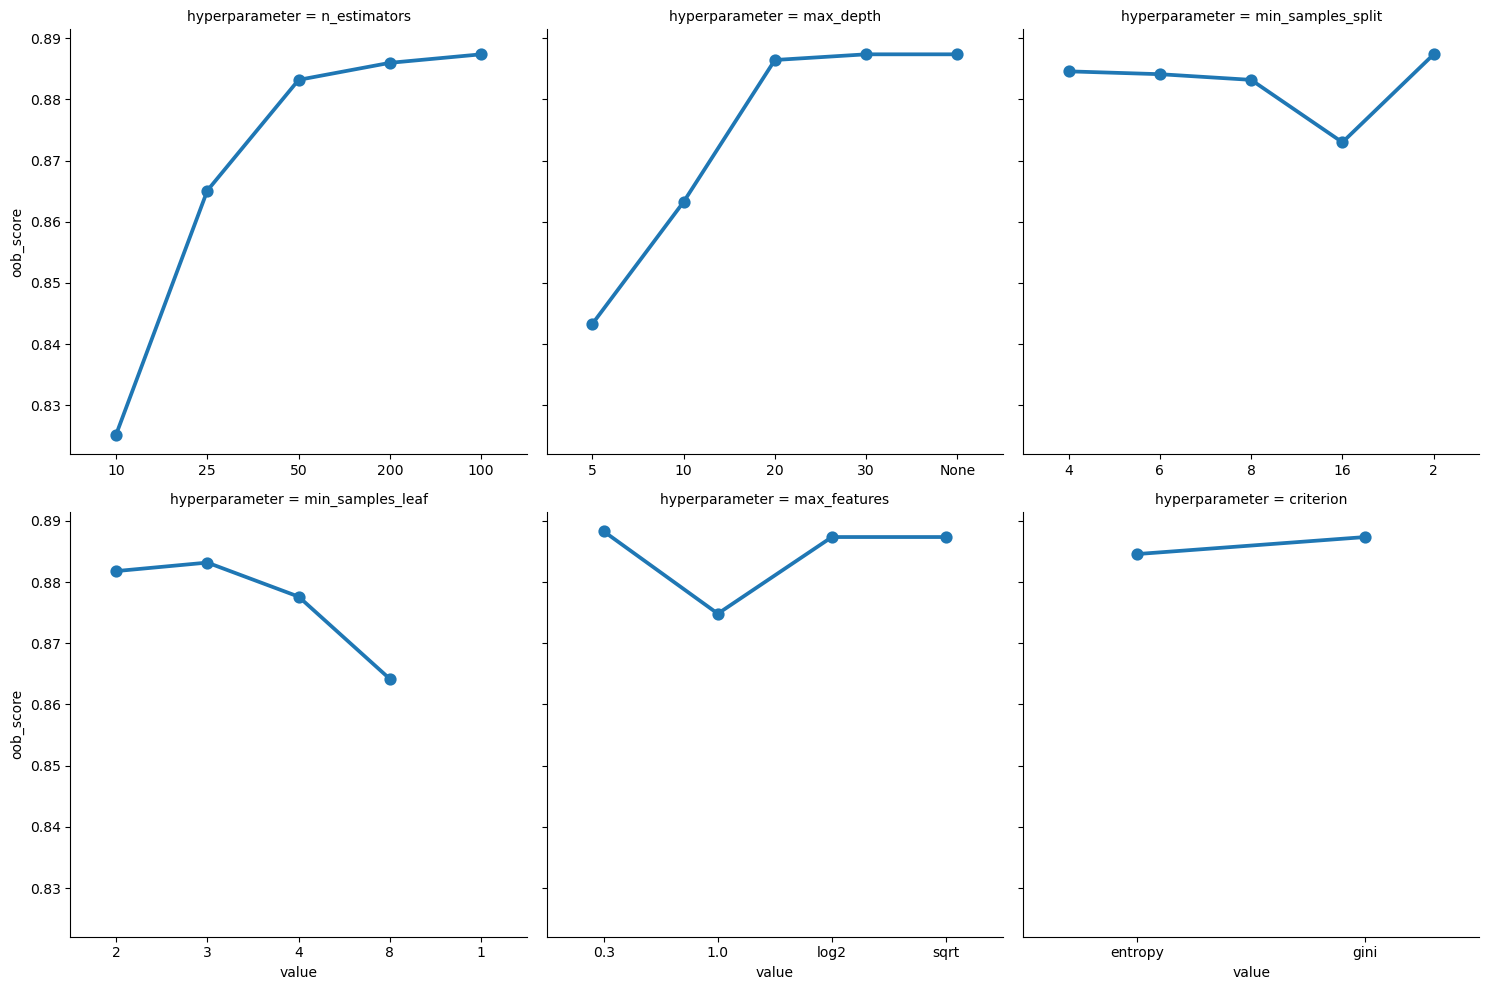

In [ ]:
### Plot the single-parameter screen
sns.catplot(
    data=full_sps_df,
    x="value",
    y="oob_score",
    col="hyperparameter",
    kind="point",
    sharey=True,
    sharex=False,
    col_wrap=3,
)
plt.show()

## Grid Search

In [14]:
# Define pipeline with PCA + Random Forest
pipeline = sk.pipeline.Pipeline([
    ('pca', sk.decomposition.PCA(n_components=32)),
    ('rf', sk.ensemble.RandomForestClassifier(random_state=SEED))
])

# Define hyperparameter grid for RandomForest
param_grid = {
    'rf__n_estimators': [50],
    'rf__max_depth': [10, 15, 20, 30],
    'rf__min_samples_split': [8],
    'rf__min_samples_leaf': [3, 4],
    'rf__max_features': ['sqrt', 'log2'],
}

# Perform GridSearchCV
grid_search = sk.model_selection.GridSearchCV(pipeline, param_grid, scoring='accuracy', cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Print best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best ROC AUC Score:", grid_search.best_score_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=3, rf__min_samples_split=8, rf__n_estimators=50; total time=   1.5s
[CV] END rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=3, rf__min_samples_split=8, rf__n_estimators=50; total time=   1.9s
[CV] END rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=3, rf__min_samples_split=8, rf__n_estimators=50; total time=   1.3s
[CV] END rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=3, rf__min_samples_split=8, rf__n_estimators=50; total time=   2.2s
[CV] END rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=3, rf__min_samples_split=8, rf__n_estimators=50; total time=   2.4s
[CV] END rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=4, rf__min_samples_split=8, rf__n_estimators=50; total time=   1.6s
[CV] END rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=4, rf__min_samples_split=8, rf__n_

In [15]:
### Convert grid search results to DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

### Keep only relevant columns
results_df = results_df[[
    "param_rf__max_depth", 
    "param_rf__min_samples_leaf", 
    "param_rf__max_features", 
    "mean_test_score"
]]

### Rename columns for readability
results_df.rename(columns={
    "param_rf__max_depth": "max_depth",
    "param_rf__min_samples_leaf": "min_samples_leaf",
    "param_rf__max_features": "max_features",
    "mean_test_score": "cv_accuracy"
}, inplace=True)

### Convert categorical values to string for Seaborn
results_df["max_features"] = results_df["max_features"].astype(str)


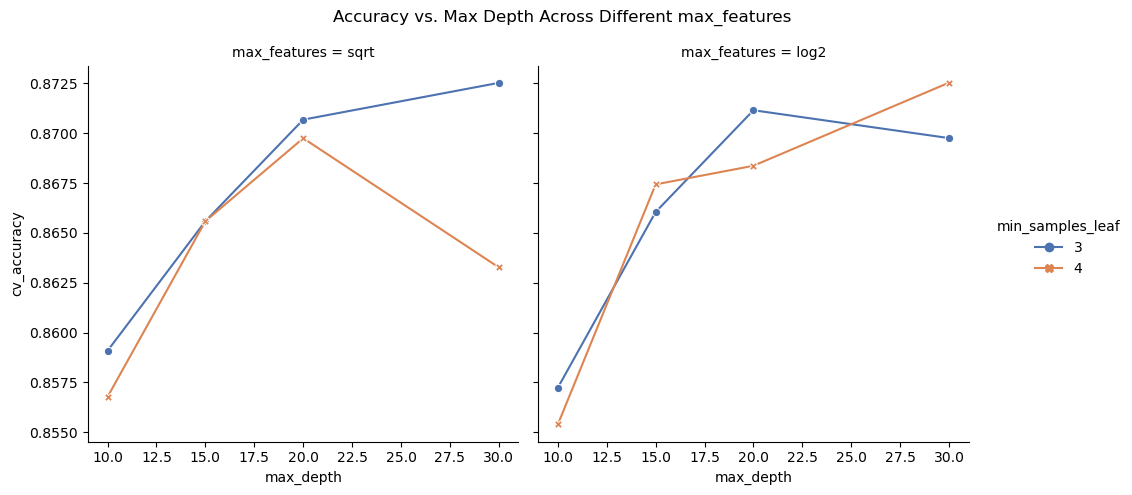

In [16]:

### Create subplots using relplot (FacetGrid)
g = sns.relplot(
    data=results_df, 
    x="max_depth", 
    y="cv_accuracy", 
    hue="min_samples_leaf", 
    style="min_samples_leaf",
    kind="line", 
    col="max_features", 
    col_wrap=2,  
    markers=True, 
    dashes=False,
    facet_kws={'sharey': True},
    palette="deep"  
)

### Set main title
g.figure.suptitle("Accuracy vs. Max Depth Across Different max_features")

### Adjust subplot spacing
g.tight_layout()

### Show the plot
plt.show()

## Final Model
Very little fluctuation was observed in the grid search (above). Any combination of parameters except `max_depth = 10` is acceptable. The chosen parameters are:  

In [13]:
### Instantiate Random Forest Classifier
rf_final = sk.ensemble.RandomForestClassifier(
    oob_score=True,  
    random_state=SEED,
    n_estimators = 50,
    max_depth = 15,
    min_samples_split = 8,
    min_samples_leaf = 3,
    max_features = 'sqrt',
)

### Fit the training data
rf_final.fit(X_train_32, y_train)

### Accuracy scores
print(f'Training Accuracy: {rf_final.score(X_train_32, y_train):.3f}')
print(f'Test Accuracy: {rf_final.score(X_test_32, y_test):.3f} (Kennard-Stone)')
print(f'Final OOB score: {rf_final.oob_score_:.3f}')


Training Accuracy: 0.965
Test Accuracy: 0.975 (Kennard-Stone)
Final OOB score: 0.872


## Conclusions
- The test accuracy of `98%` is miss-leading and demonstrates that Kennard-Stone is not a suitable splitting method for this application. 
- Based on the cross-validation results and the out-of bag score a test accuracy of `87%` is assumed. 
- A train-test-gap of `10%` is still acceptable, but suggest indicates moderate overfitting.  

# Applicability domain

The applicability domain of Random Forest models can be defined based on the classification agreement among individual trees:
- 50 trees were trained (`n_estimators` = `50`).
- `rf_final.estimators_` returns a list with the individual trees (allowing the investigation of individual trees)
- Each cmpd is classified by each trees 
- For each novel or test cmpd the closest training cmpd is determined. 
    - The proximity is defined as classification agreement among individual trees e.g. `40 / 50` trees classify both cmpds in agreement --> `80%` proximity 
- A threshold for decidability is defined by the user when the model is trained. Values of `50-75%` are common. 
- Novel cmpds below the threshold can not be evaluated by the mode. 

The code to calculate the applicability domain for a `RandomForestClassifier` is implemented in the class [`utils.sk_qsar.RfClfAppDom`](../utils/sk_qsar.py)

In [15]:
### Instantiate the class
rf_app_dom = sk_qsar.RfClfAppDom(rf_final, morgan.df.loc[test_idx], pca_model=pca_32)

### Fit the model
rf_app_dom.fit(X_train_32, X_test_32)

### Define the threshold
rf_app_dom.def_threshold(threshold=0.6)

### Predict the applicability domain
AD_df = rf_app_dom.predict()

Threshold: 0.6
0 (0.0 %) test cmpds outside the applicability domain
count   240.00
mean      0.94
std       0.06
min       0.72
25%       0.92
50%       0.96
75%       0.98
max       1.00
Name: AD_value, dtype: float64


Having picked the test compounds from a very homogeneous data set using Kennard-Stone, it is not surprising that all test compounds are within AD. 

# Visual inspection

,Mol,AD_status,AD_value,true_label,pred_label,pred_proba
ID,,,,,,
CHEMBL3957312,,True,0.80,0,1,0.65
CHEMBL3650966,,True,0.94,0,1,0.92
CHEMBL3650861,,True,0.92,0,1,0.85
CHEMBL3967404,,True,0.72,0,1,0.65

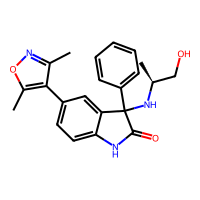
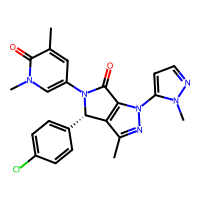
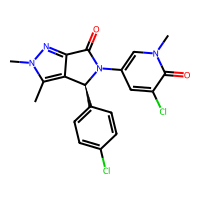
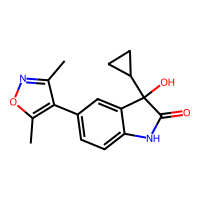

In [28]:
### Add the true labels, predicted labels, and probabilities
AD_df['true_label'] = y_test.astype(int)
AD_df['pred_label'] = rf_final.predict(X_test_32).astype(int)
AD_df['pred_proba'] = rf_final.predict_proba(X_test_32)[:, 1]

### Masks for false positives and false negatives
fp_mask = (AD_df['true_label'] == 0) & (AD_df['pred_label'] == 1)
fn_mask = (AD_df['true_label'] == 1) & (AD_df['pred_label'] == 0)

### Display the false positives
render_mol(AD_df[fp_mask])

,Mol,AD_status,AD_value,true_label,pred_label,pred_proba
ID,,,,,,
CHEMBL4798044,,True,0.96,1,0,0.28
CHEMBL5415794,,True,0.72,1,0,0.49

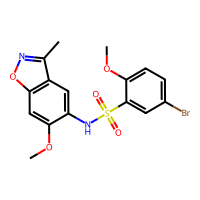
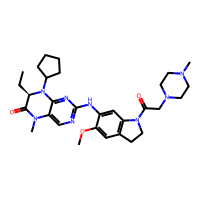

In [29]:
### Display the false negatives
render_mol(AD_df[fn_mask])

- It is noteworthy that although both false positives and false negatives are predicted with varying agreement with the training data `0.72 < AD_value < 0.96` they are all below the median AD_value. 
- The confidence confidence `pred_proba` loosely correlates with AD_value. 
- All false positives exhibit a 5-membered lactam fused to an aromatic ring. This motive was also present in multiple activity cliffs ([SALI](../01_eda/02_activity_cliffs.ipynb)) which can explain the strong variance.   

# Export AD model
All required algorithms for predicting novel cmpds are included.  

In [17]:
with open("../data/03_rf_ad_class.pkl", "wb") as file:
    pickle.dump(rf_app_dom, file)